# CSI multi-task model v1.3 — hrc_ur10_cell (Stage 2)

Train a small network to read one static CSI snapshot and predict
**presence / count / safety-zone** for the UR10 cell, as an
**experiment sweep**: one run per config, all results collected into a
single comparison table (apples-to-apples, no re-running by hand).

**Model** — the verified Stage-1 tiny ResNet (~406k params); shared neck; four
heads: presence (binary), count (0/1/2), zone (4-class, `clf` mode) and a
distance scalar (`dist` mode). The input channel count is now read from the
data, so it grows automatically (8 → 12) when a gain channel is added.

**L3 physics hybrid.** With `hybrid=True`, a short vector of **hand-computed
physics features** (per-link log-energy, per-link delay centroid, coarse
angle-of-arrival) is concatenated to the CNN features before the neck. It is
**not** used in the v1.3 live sweep — kept in code; `hybrid=False` reproduces the
v0 model exactly.

**New in v1.3 — the GAIN experiment.** Tests whether the true absolute wave gain
(path loss / body absorption), which `normalize=True` divides out of the traced
CSI, carries information the model isn't already getting from `re/im`.
- **`build_data` gains an `add_gain` flag**: `None` (unchanged, 8 channels) /
  `'norm'` (adds a `log|bgsub|` normalised-magnitude channel = a matched-capacity
  **control**) / `'abs'` (adds the **true** `log|bgsub_abs|` channel; needs the
  regenerated `*_abs` arrays — guarded with a clear error if the npz lacks them).
- **Sweep = the gain triple at full 35k, single run each** (seeds dropped):
  `delayangle_fix` (no gain, 406,089 params) / `delayangle_fix_normmag` (control)
  / `delayangle_fix_absgain` (both 407,241 params = matched capacity). The honest
  comparison is **absgain vs the normmag control**, not vs the bare baseline —
  that isolates absolute *content* from the extra channel's capacity.
- **`RUN_LC = False`** — the learning curve is skipped (guarded, so its plot cell
  is a clean no-op); `DETAIL_NAME` points at `delayangle_fix_absgain`.
- Non-gain configs are **byte-for-byte v1.2**, so nothing else drifts.

*(Lineage.)* The v1.1 complex / safety-fix / representation ablations were
settled at 8k and are kept **commented** in the CONFIG cell (uncomment to
re-include; slow at 35k). The v1.2 50k data-scaling + L3 generalisation runs are
also commented there; their findings stand from earlier sessions.

**Each run is one config** in `EXPERIMENTS` (CONFIG cell). Axes: `input`
(`bgsub`/`raw`), `rep` (`complex`/`delay`/`delayangle`), `zone_mode`
(`dist`/`clf`), `split_mode` (`stored`/`clutter_holdout`), `hybrid`, `add_gain`.
Results land in `results_df` + `results_experiments.csv`; per-run checkpoints
save as `csi_multitask_<name>.pt`.

> **GPU.** Each run trains a fresh model; at 35k this is a real training job —
> use the lab `.venv-model` GPU env (the Blackwell is fast for training), or a
> fresh Colab GPU runtime. The setup cell auto-loads the regenerated dataset (it
> also looks for the `_8k` name).

In [1]:
# ================================================================
# SETUP + FILE LOCATION
# Runs UNCHANGED on both Colab and the school lab machine.
#   - Colab : upload the notebook + .npz into /content
#   - Lab   : keep the notebook + .npz in the same folder
# torch + sklearn + pandas are preinstalled on Colab; on the lab
# machine they come from the .venv-model (GPU torch) install.
# ================================================================
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (balanced_accuracy_score, f1_score,
                             confusion_matrix, recall_score)

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False
IN_COLAB = _in_colab()

# v1.2: prefer the 50k set; fall back to the 8k dynamic set, then the anchor.
DATA_CANDIDATES = ['hrc_ur10_dynamic_clutter_50k.npz',    # 50k (loads first)
                   'hrc_ur10_dynamic_clutter_8k.npz',     # 8k regen (has gain arrays)
                   'hrc_ur10_dynamic_clutter_v0.npz',     # 8k dynamic, fallback
                   'hrc_ur10_cell_data_v0_robot.npz']     # Scene 1 anchor

# Search roots in priority order. Direct hit first (fast), then a
# recursive search as a fallback -- so it "just works" wherever the
# file sits, without editing paths per machine.
_roots = []
if IN_COLAB:
    _roots.append(Path('/content'))
_roots.append(Path.cwd())                                  # notebook's own folder
_roots.append(Path(r'C:/Users/u5737297/Documents/wifi sensing'))  # lab default (ignored if absent)

def _find(name, roots):
    seen = set()
    for r in roots:
        if (not r) or (r in seen) or (not r.exists()):
            continue
        seen.add(r)
        direct = r / name
        if direct.exists():
            return direct
        hit = next(iter(r.rglob(name)), None)   # recursive fallback
        if hit:
            return hit
    return None

NPZ_PATH = None
for _name in DATA_CANDIDATES:
    _hit = _find(_name, _roots)
    if _hit is not None:
        NPZ_PATH = str(_hit); DATA_NAME = _name; break
if NPZ_PATH is None:
    _searched = '\n  '.join(str(r) for r in _roots)
    raise FileNotFoundError(
        'No dataset found (' + ' or '.join(DATA_CANDIDATES) + '). Put one beside '
        f'this notebook (lab) or upload to /content (Colab). Searched:\n  {_searched}')

BASE_DIR = str(Path(NPZ_PATH).parent)   # outputs (the .pt checkpoint) saved here

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('env  :', 'Colab' if IN_COLAB else 'local/lab', '| torch', torch.__version__, '| device', DEVICE)
print('data :', NPZ_PATH)
print('out  :', BASE_DIR)

env  : local/lab | torch 2.11.0+cu128 | device cuda
data : c:\Users\u5737297\Documents\wifi sensing\stage2\hrc_ur10_dynamic_clutter_50k.npz
out  : c:\Users\u5737297\Documents\wifi sensing\stage2


## Data understanding (before modelling)

The data is simulated, but it still pays to look at it before training. These
three cells check the basics only:

1. **What is in the file** — the arrays the npz holds, plus a **per-sample
   pandas DataFrame** (`df`) of the labels and metadata (one row per snapshot:
   presence, count, zone, split, worker positions, and cheap per-sample
   magnitude summaries).
2. **Label balance** — how presence / count / zone are distributed, overall
   and across the train/val/test split (imbalance is why we use balanced
   accuracy and class weights later).
3. **Is the worker visible in the CSI** — the mean background-subtracted
   magnitude should be ~0 with nobody present and grow as workers are added,
   confirming the signal we want to sense is actually there.

**Storage note.** The dataset stays in the `.npz` (efficient, lossless, and
the only sensible home for the 4-D **complex** CSI tensor — pandas/CSV can't
hold that). We keep the CSI as **numpy** for the model, and derive the
**pandas** `df` from the same npz at load time for the tabular labels/metadata.
Nothing new is written to disk. Nothing here trains or changes the model — it
is a sanity check on the input. The cells use `df` and `*0` variables, so they
do not interfere with the modelling pipeline below.

In [2]:
# ================================================================
# DATA UNDERSTANDING (1/3) -- what is in the file + build the
# per-sample DataFrame (labels/metadata in pandas; CSI stays numpy)
# ================================================================
z0 = np.load(NPZ_PATH, allow_pickle=True)

# what the npz holds, as a small table
inv = pd.DataFrame([(k, str(z0[k].shape), str(z0[k].dtype)) for k in z0.files],
                   columns=['array', 'shape', 'dtype'])
print('npz contents:')
print(inv.to_string(index=False))

# CSI tensor stays numpy: 4-D complex -> not a DataFrame (see note below)
csi0 = z0['csi_bgsub']
N, M_AP, K_TX, N_SUB = csi0.shape
print(f'\nCSI tensor [N, M_AP, K_TX, N_sub] = [{N}, {M_AP}, {K_TX}, {N_SUB}], '
      f'{csi0.dtype}  -> kept as numpy for the model')
print('NaNs -> csi_raw:', int(np.isnan(z0['csi_raw']).sum()),
      '| csi_bgsub:', int(np.isnan(csi0).sum()))

# per-sample labels + metadata -> one row per snapshot
zone_labels = [str(s) for s in z0['zone_labels']]      # ['none','green','yellow','red']
pos = z0['positions']                                  # [N, 2 workers, 2 coords (x,y)]
df = pd.DataFrame({
    'presence': z0['presence'].astype(int),
    'count':    z0['count'].astype(int),
    'zone':     z0['zone'].astype(int),
    'split':    pd.Categorical(z0['split'].astype(str),
                               categories=['train', 'val', 'test']),
})
df['zone_name'] = pd.Categorical.from_codes(df['zone'], categories=zone_labels)
df['worker0_x'], df['worker0_y'] = pos[:, 0, 0], pos[:, 0, 1]
df['worker1_x'], df['worker1_y'] = pos[:, 1, 0], pos[:, 1, 1]
if 'agv_count' in z0.files:                            # dynamic-clutter dataset
    df['agv_count'] = z0['agv_count'].astype(int)
# cheap per-sample signal summaries (mean magnitude over antennas x subcarriers)
df['mean_abs_raw']   = np.abs(z0['csi_raw']).mean(axis=(1, 2, 3))
df['mean_abs_bgsub'] = np.abs(z0['csi_bgsub']).mean(axis=(1, 2, 3))

print(f'\nper-sample DataFrame: {df.shape[0]} rows x {df.shape[1]} cols'
      + ('  (with AGV clutter)' if 'agv_count' in df else '  (anchor, no clutter)'))
df.head()

npz contents:
                array             shape     dtype
              csi_raw (50000, 4, 4, 64) complex64
            csi_bgsub (50000, 4, 4, 64) complex64
            csi_empty        (4, 4, 64) complex64
          csi_raw_abs (50000, 4, 4, 64) complex64
        csi_bgsub_abs (50000, 4, 4, 64) complex64
        csi_empty_abs        (4, 4, 64) complex64
                count          (50000,)      int8
             presence          (50000,)      int8
                 zone          (50000,)      int8
            positions     (50000, 2, 2)   float32
            agv_count          (50000,)      int8
        agv_positions     (50000, 3, 2)   float32
                split          (50000,)       <U5
              freq_hz                ()   float64
      num_subcarriers                ()     int64
subcarrier_spacing_hz                ()   float64
                 k_tx                ()     int64
                 m_ap                ()     int64
              human_z               

,presence,count,zone,split,zone_name,worker0_x,worker0_y,worker1_x,worker1_y,agv_count,mean_abs_raw,mean_abs_bgsub
0,1,2,1,train,green,-2.805116,-1.982453,0.47834,-3.283746,3,0.940685,0.067029
1,1,1,1,train,green,3.662417,-2.771291,NaN,NaN,1,0.943148,0.031592
2,1,1,1,test,green,4.625093,1.320673,NaN,NaN,1,0.945098,0.066679
3,0,0,0,train,none,NaN,NaN,NaN,NaN,0,0.943257,0.000016
4,0,0,0,train,none,NaN,NaN,NaN,NaN,2,0.943356,0.008256


overall label balance:
  presence : {0: 16617, 1: 33383}
  count    : {0: 16617, 1: 16861, 2: 16522}
  zone     : {'none': 16617, 'green': 18713, 'yellow': 8734, 'red': 5936}

zone x split (counts):
split      train   val  test
zone_name                   
none       11633  2492  2492
green      13115  2763  2835
yellow      6100  1327  1307
red         4154   917   865


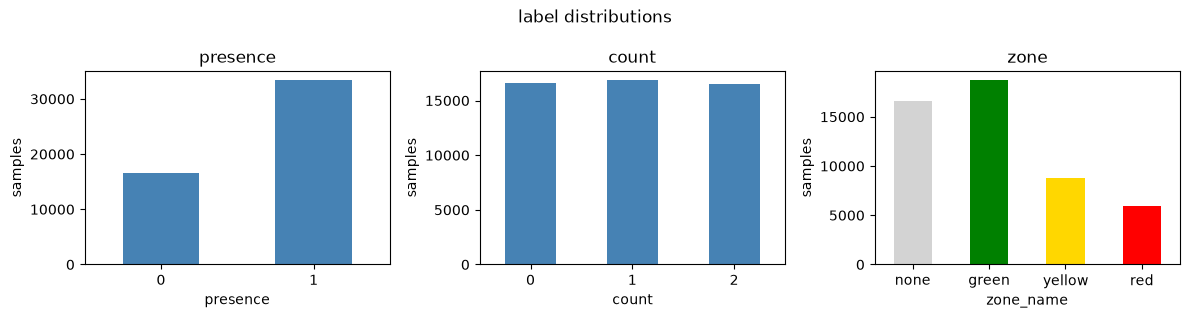

In [3]:
# ================================================================
# DATA UNDERSTANDING (2/3) -- label balance (pandas)
# ================================================================
print('overall label balance:')
print('  presence :', df['presence'].value_counts().sort_index().to_dict())
print('  count    :', df['count'].value_counts().sort_index().to_dict())
print('  zone     :', df['zone_name'].value_counts()[zone_labels].to_dict())

print('\nzone x split (counts):')
print(pd.crosstab(df['zone_name'], df['split']))

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
df['presence'].value_counts().sort_index().plot.bar(
    ax=ax[0], color='steelblue', title='presence', rot=0)
df['count'].value_counts().sort_index().plot.bar(
    ax=ax[1], color='steelblue', title='count', rot=0)
df['zone_name'].value_counts()[zone_labels].plot.bar(
    ax=ax[2], color=['lightgray', 'green', 'gold', 'red'], title='zone', rot=0)
for a in ax:
    a.set_ylabel('samples')
fig.suptitle('label distributions'); fig.tight_layout(); plt.show()

mean background-subtracted magnitude by worker count:
           mean       std   size
count                           
0      0.015907  0.021475  16617
1      0.047616  0.043216  16861
2      0.073009  0.054336  16522

overall  mean |csi_raw|   = 0.9434
overall  mean |csi_bgsub| = 0.0455

mean |csi_bgsub| by (human count x agv count):
agv_count      0      1      2      3
count                                
0          0.000  0.012  0.022  0.030
1          0.036  0.044  0.052  0.058
2          0.064  0.069  0.077  0.081


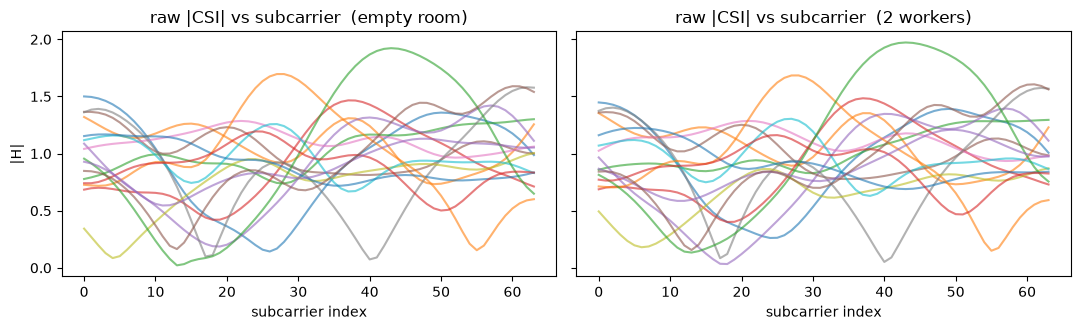

In [4]:
# ================================================================
# DATA UNDERSTANDING (3/3) -- is the worker visible in the CSI?
# Background subtraction removes the empty room, so |csi_bgsub|
# should be ~0 with nobody there and grow as workers are added.
# ================================================================
sig = df.groupby('count')['mean_abs_bgsub'].agg(['mean', 'std', 'size'])
print('mean background-subtracted magnitude by worker count:')
print(sig)
print('\noverall  mean |csi_raw|   =', round(float(df['mean_abs_raw'].mean()), 4))
print('overall  mean |csi_bgsub| =', round(float(df['mean_abs_bgsub'].mean()), 4))

# with clutter, condition on (human count x agv count): count-0 rows are no
# longer ~0 -- the AGV perturbation is the confound the model must see past.
if 'agv_count' in df:
    print('\nmean |csi_bgsub| by (human count x agv count):')
    print(df.pivot_table(index='count', columns='agv_count',
                         values='mean_abs_bgsub', aggfunc='mean').round(3))

# one empty vs one occupied snapshot: raw amplitude across subcarriers (from the tensor)
i_empty  = int(df.index[df['count'] == 0][0])
i_worker = int(df.index[df['count'] == 2][0])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for a, (ttl, idx) in zip(ax, [('empty room', i_empty), ('2 workers', i_worker)]):
    amp = np.abs(z0['csi_raw'][idx]).reshape(M_AP * K_TX, N_SUB)   # 16 links x 64 subcarriers
    a.plot(amp.T, alpha=0.6)
    a.set_title(f'raw |CSI| vs subcarrier  ({ttl})')
    a.set_xlabel('subcarrier index')
ax[0].set_ylabel('|H|')
fig.tight_layout(); plt.show()

In [ ]:
# ================================================================
# CONFIG -- shared hyperparameters + the EXPERIMENT SWEEP (v1.3, 50k set)
# ================================================================
# shared across every run
BATCH = 128
EPOCHS = 120
LR = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT_P = 0.2
SUBCARRIER_DROPOUT = 0.1
LAMBDA_DIST = 1.0         # default weight of the distance-regression loss (dist mode)
RED_SAFETY_MARGIN = 0.0   # default red-threshold margin (m); per-run 'red_margin' overrides

STEM_CH = 32
STAGE_CH = [32, 64, 96, 96]
STAGE_DS = [False, True, True, True]
N_COUNT, N_ZONE = 3, 4
ZONE_NAMES = ['none', 'green', 'yellow', 'red']

# Per-run keys (defaults in brackets):
#   input('bgsub') | rep('complex') | zone_mode('dist') | split_mode('stored')
#   red_margin(0.0) | dist_weighted(False) | hybrid(False) | phys_angle(True) | add_gain(None)
#
# EXPERIMENTS = the v1.3 GAIN triple. The learning curve (below) is a SEPARATE
# run of the current best model across data sizes. The v1.1/v1.2 ablations are
# kept commented (settled earlier; uncomment to re-include, slow at 35k).
EXPERIMENTS = [
    # -- GAIN EXPERIMENT (v1.3): baseline vs normalised-mag CONTROL vs TRUE absolute gain --
    #    add_gain: None (no channel) | 'norm' (log|bgsub|, matched-capacity control) | 'abs' (log|bgsub_abs|)
    dict(name='delayangle_fix',         input='bgsub', rep='delayangle', zone_mode='dist', split_mode='stored', red_margin=0.4, dist_weighted=True),
    dict(name='delayangle_fix_normmag', input='bgsub', rep='delayangle', zone_mode='dist', split_mode='stored', red_margin=0.4, dist_weighted=True, add_gain='norm'),
    dict(name='delayangle_fix_absgain', input='bgsub', rep='delayangle', zone_mode='dist', split_mode='stored', red_margin=0.4, dist_weighted=True, add_gain='abs'),
    # -- v1.2 generalisation runs (uncomment to re-run) --
    # dict(name='hybrid_best_gen',    input='bgsub', rep='delayangle', zone_mode='dist', split_mode='clutter_holdout', red_margin=0.4, dist_weighted=True, hybrid=True),
    # dict(name='delayangle_fix_gen', input='bgsub', rep='delayangle', zone_mode='dist', split_mode='clutter_holdout', red_margin=0.4, dist_weighted=True),
    # -- settled at 8k (v1.1); uncomment to re-include (slow at 35k) --
    # dict(name='dist_base',     input='bgsub', rep='complex', zone_mode='dist', split_mode='stored'),
    # dict(name='dist_margin',   input='bgsub', rep='complex', zone_mode='dist', split_mode='stored', red_margin=0.4),
    # dict(name='dist_weighted', input='bgsub', rep='complex', zone_mode='dist', split_mode='stored', dist_weighted=True),
    # dict(name='dist_both',     input='bgsub', rep='complex', zone_mode='dist', split_mode='stored', red_margin=0.4, dist_weighted=True),
    # dict(name='zone_clf',      input='bgsub', rep='complex', zone_mode='clf',  split_mode='stored'),
    # dict(name='delay',         input='bgsub', rep='delay',      zone_mode='dist', split_mode='stored'),
    # dict(name='delayangle',    input='bgsub', rep='delayangle', zone_mode='dist', split_mode='stored'),
    # dict(name='hybrid_complex', input='bgsub', rep='complex',   zone_mode='dist', split_mode='stored', hybrid=True),
]

# LEARNING-CURVE model = the CURRENT BEST model, delayangle_fix (no hybrid; the
# L3 hybrid washed out at 50k). Distinct name ('lc_delayangle_fix') so its
# full-size row/checkpoint does NOT collide with the delayangle_fix gain-sweep row.
LC_CFG = dict(name='lc_delayangle_fix', input='bgsub', rep='delayangle', zone_mode='dist',
              split_mode='stored', red_margin=0.4, dist_weighted=True)
LC_NAME = 'lc_delayangle_fix'
# span the whole 50k (train ~35k). The full training set is appended as the last
# point; its full-size model is saved and added to the table + DETAIL.
LC_SIZES = [1000, 2000, 4000, 8000, 16000, 32000]

RUN_LC = True                # v1.3: RUN the learning curve of the current best model
DETAIL_NAME = 'delayangle_fix_absgain'   # detail plots for the gain run (present when the sweep runs)
torch.manual_seed(0); np.random.seed(0)
print(f'{len(EXPERIMENTS)} sweep configs + a learning curve on {LC_NAME}')
print('sweep:', [e['name'] for e in EXPERIMENTS])

In [6]:
# ================================================================
# DATA: load once; build_data(cfg) applies the representation + split
# per config (CSI stays numpy; distance target for the ordinal head).
# v1: also builds the L3 HYBRID physics-feature vector when cfg['hybrid'].
# ================================================================
z = np.load(NPZ_PATH, allow_pickle=True)
_HAS_AGV = 'agv_count' in z.files
_HAS_ABS = 'csi_bgsub_abs' in z.files
print('dataset:', DATA_NAME, '| has AGV clutter:', _HAS_AGV, '| has abs-gain:', _HAS_ABS)

def representation(c, rep):
    # complex [N,M_AP,K_TX,N_sub] -> real [N, 2*K_TX, M_AP, N_sub]
    if rep == 'complex':      t = c                                  # frequency domain
    elif rep == 'delay':      t = np.fft.ifft(c, axis=-1)            # -> delay domain
    elif rep == 'delayangle': t = np.fft.ifft(np.fft.fft(c, axis=1), axis=-1)  # angle x delay
    else: raise ValueError(f'unknown rep={rep}')
    s = np.stack([t.real, t.imag], axis=1)          # [N,2,M_AP,K_TX,N_sub]
    s = np.transpose(s, (0, 1, 3, 2, 4))            # [N,2,K_TX,M_AP,N_sub]
    return s.reshape(c.shape[0], 2*c.shape[2], c.shape[1], c.shape[3]).astype(np.float32)

def physics_features(c, use_angle=True):
    # L3 HYBRID -- hand-computed physics cues per snapshot, from the complex
    # (background-subtracted) CSI c [N, M_AP, K_TX, N_sub]. Returns [N, phys_dim].
    # These are signal-processing steps we would otherwise hope the CNN
    # rediscovers; handing them over is the "add physics to the model" rung.
    N = c.shape[0]
    # (1) per-link log-energy -- WHICH links the disturbance moved (fingerprint)
    energy = (np.abs(c) ** 2).sum(axis=-1).reshape(N, -1)                 # [N,16]
    log_energy = np.log(energy + 1e-8).astype(np.float32)
    # (2) per-link delay centroid -- HOW FAR the echo travelled (sub-bin range)
    cir = np.abs(np.fft.ifft(c, axis=-1))                                # [N,M_AP,K_TX,N_sub] delay domain
    taps = np.arange(c.shape[-1])
    centroid = (cir * taps).sum(-1) / (cir.sum(-1) + 1e-8)               # [N,M_AP,K_TX]
    centroid = (centroid / c.shape[-1]).reshape(N, -1).astype(np.float32)  # normalized [N,16]
    feats = [log_energy, centroid]
    # (3) optional coarse angle-of-arrival per TX from the AP array (4 antennas)
    if use_angle:
        ang = np.abs(np.fft.fft(c, axis=1))                              # FFT over M_AP antennas
        doa = (ang.sum(-1).argmax(axis=1) / c.shape[1]).astype(np.float32)  # [N,K_TX] peak-dir per TX
        feats.append(doa)
    return np.concatenate(feats, axis=1).astype(np.float32)              # [N, phys_dim]

def build_data(cfg):
    csi = z['csi_bgsub'] if cfg['input'] == 'bgsub' else z['csi_raw']
    presence = z['presence'].astype(np.int64); count = z['count'].astype(np.int64)
    zone = z['zone'].astype(np.int64); split = z['split'].astype(str)
    agv = (z['agv_count'].astype(np.int64) if _HAS_AGV else np.zeros(len(count), np.int64))
    N = len(count)
    ZCENTER = np.asarray(z['zone_center'], np.float32)
    RED_R = float(z['red_radius']); YEL_R = float(z['yellow_radius'])
    X = representation(csi, cfg['rep'])
    # v1.3 GAIN EXPERIMENT: optionally append a log-magnitude channel (K_TX extra
    # channels). add_gain='abs' = TRUE absolute gain (needs the regenerated *_abs
    # arrays); 'norm' = normalised-magnitude CONTROL (matched capacity); None = off.
    _ag = cfg.get('add_gain')
    if _ag:
        if _ag == 'abs':
            if not _HAS_ABS:
                raise RuntimeError(f"add_gain='abs' needs csi_bgsub_abs, but {DATA_NAME} has no "
                                   "*_abs arrays -> regenerate with data_generation_ur10_parallel.")
            _gsrc = z['csi_bgsub_abs'] if cfg['input'] == 'bgsub' else z['csi_raw_abs']
        elif _ag == 'norm':
            _gsrc = csi                                   # normalised magnitude (shape only)
        else:
            raise ValueError(f"add_gain={_ag!r} (expected 'abs' | 'norm' | None)")
        _g = np.log(np.abs(_gsrc) + 1e-9).astype(np.float32)          # [N,M_AP,K_TX,N_sub]
        _g = np.transpose(_g, (0, 2, 1, 3))                           # -> [N,K_TX,M_AP,N_sub]
        X = np.concatenate([X, _g], axis=1)                           # + K_TX channels
    # split
    if cfg['split_mode'] == 'clutter_holdout' and (agv > 2).any():
        te = agv >= 3; _tv = agv <= 2
        _rs = np.random.default_rng(0); _idx = np.where(_tv)[0]; _rs.shuffle(_idx)
        va = np.zeros(N, bool); va[_idx[:int(0.15*len(_idx))]] = True; tr = _tv & ~va
    else:
        tr, va, te = split == 'train', split == 'val', split == 'test'
    # optional: subsample the TRAIN set (learning curve); val/test unchanged
    _tn = cfg.get('train_n')
    if _tn is not None and _tn < int(tr.sum()):
        _keep = np.random.default_rng(123).choice(np.where(tr)[0], size=_tn, replace=False)
        tr = np.zeros(N, bool); tr[_keep] = True
    # standardize CSI on train only
    xm = X[tr].mean(axis=(0, 2, 3), keepdims=True); xs = X[tr].std(axis=(0, 2, 3), keepdims=True) + 1e-6
    Xn = (X - xm) / xs
    # L3 hybrid physics features (from the SAME input CSI; most meaningful on
    # bgsub). phys_dim=0 when hybrid off -> the model is exactly v0.
    if cfg.get('hybrid', False):
        Xp = physics_features(csi, use_angle=cfg.get('phys_angle', True))
        pm = Xp[tr].mean(0, keepdims=True); ps = Xp[tr].std(0, keepdims=True) + 1e-6
        Xp = ((Xp - pm) / ps).astype(np.float32)                        # z-score on train only
    else:
        Xp = np.zeros((N, 0), np.float32); pm = ps = None
    # nearest-human distance-to-robot (dist zone target); NaN->0, masked by presence
    pos = z['positions']; _d = np.hypot(pos[..., 0] - ZCENTER[0], pos[..., 1] - ZCENTER[1])
    _d = np.where(np.isnan(_d), np.inf, _d).min(axis=1)
    dist_fill = np.nan_to_num(np.where(count > 0, _d, np.nan), nan=0.0).astype(np.float32)
    return dict(Xn=Xn, Xp=Xp, phys_dim=int(Xp.shape[1]), presence=presence, count=count,
                zone=zone, agv=agv, tr=tr, va=va, te=te, dist_fill=dist_fill,
                x_mean=xm, x_std=xs, phys_mean=pm, phys_std=ps, RED_R=RED_R, YEL_R=YEL_R)

print('build_data ready | reps: complex / delay / delayangle | + L3 physics features (hybrid)')

dataset: hrc_ur10_dynamic_clutter_50k.npz | has AGV clutter: True | has abs-gain: True
build_data ready | reps: complex / delay / delayangle | + L3 physics features (hybrid)


In [7]:
# ================================================================
# MODEL: Stage-1 tiny ResNet backbone + shared neck + 4 heads
#   presence (binary) | count (3) | zone (4, clf mode) | dist (1, dist mode)
# L3 HYBRID (v1): optional hand-computed physics features (phys_dim>0) are
#   concatenated to the pooled CNN features before the neck. phys_dim=0 ->
#   byte-for-byte the v0 model, so non-hybrid runs are unchanged.
# ================================================================
class BasicBlock(nn.Module):
    """ResNet basic block. Stride (1, s) downsamples ONLY the last (width) axis."""
    def __init__(self, cin, cout, stride_w=1):
        super().__init__()
        s = (1, stride_w)
        self.conv1 = nn.Conv2d(cin, cout, 3, stride=s, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.proj = None
        if cin != cout or stride_w != 1:
            self.proj = nn.Sequential(nn.Conv2d(cin, cout, 1, stride=s, bias=False),
                                      nn.BatchNorm2d(cout))
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        idt = x if self.proj is None else self.proj(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + idt)


class CSINetMulti(nn.Module):
    def __init__(self, in_ch=8, stem=STEM_CH, stage_ch=STAGE_CH, stage_ds=STAGE_DS,
                 p=DROPOUT_P, phys_dim=0):
        super().__init__()
        self.phys_dim = phys_dim
        self.stem = nn.Sequential(nn.Conv2d(in_ch, stem, 3, padding=1, bias=False),
                                  nn.BatchNorm2d(stem), nn.ReLU(inplace=True))
        blocks, c = [], stem
        for cout, ds in zip(stage_ch, stage_ds):
            blocks.append(BasicBlock(c, cout, stride_w=2 if ds else 1)); c = cout
        self.stages = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        # neck input = pooled CNN features (c) + hand-computed physics (phys_dim)
        self.neck = nn.Sequential(nn.Linear(c + phys_dim, 64), nn.ReLU(inplace=True), nn.Dropout(p))
        self.head_presence = nn.Linear(64, 1)
        self.head_count = nn.Linear(64, N_COUNT)
        self.head_zone = nn.Linear(64, N_ZONE)   # ZONE_MODE='clf'
        self.head_dist = nn.Linear(64, 1)        # ZONE_MODE='dist' (metres)

    def forward(self, x, phys=None):
        f = self.pool(self.stages(self.stem(x))).flatten(1)   # [B, c] learned features
        if self.phys_dim:
            f = torch.cat([f, phys], dim=1)                   # + hand-computed physics
        f = self.neck(f)
        return (self.head_presence(f).squeeze(1), self.head_count(f),
                self.head_zone(f), self.head_dist(f).squeeze(1))

print(f'model params (no physics)  : {sum(p.numel() for p in CSINetMulti().parameters()):,}')
print(f'model params (phys_dim=36) : {sum(p.numel() for p in CSINetMulti(phys_dim=36).parameters()):,}')

model params (no physics)  : 406,089
model params (phys_dim=36) : 408,393


In [8]:
# ================================================================
# run_experiment(cfg) -- build data, train a fresh model, evaluate.
# Returns a metrics ROW + a DETAIL dict (predictions + history) and
# saves a per-run checkpoint (unless cfg['no_save']). Reused by the sweep.
# v1: threads the L3 physics-feature vector (b['Xp']) through the loaders
#     and into model(x, phys); phys_dim=0 -> identical to v0.
# ================================================================
def run_experiment(cfg):
    b = build_data(cfg); RED_R, YEL_R = b['RED_R'], b['YEL_R']; zm = cfg['zone_mode']
    RED_M = cfg.get('red_margin', RED_SAFETY_MARGIN)     # per-run red decision margin
    LAM   = cfg.get('lambda_dist', LAMBDA_DIST)
    DISTW = cfg.get('dist_weighted', False)              # weight distance loss by zone rarity

    def loader(m, sh):
        ds = TensorDataset(torch.tensor(b['Xn'][m]), torch.tensor(b['Xp'][m]),
                           torch.tensor(b['presence'][m]), torch.tensor(b['count'][m]),
                           torch.tensor(b['zone'][m]), torch.tensor(b['dist_fill'][m]))
        return DataLoader(ds, batch_size=BATCH, shuffle=sh, drop_last=False)
    dl_tr, dl_va, dl_te = loader(b['tr'], True), loader(b['va'], False), loader(b['te'], False)

    zbal = np.bincount(b['zone'][b['tr']], minlength=N_ZONE).astype(np.float32)
    zw = (zbal.sum() / (N_ZONE * np.maximum(zbal, 1)))
    zone_w = torch.tensor(zw / zw.mean(), dtype=torch.float32, device=DEVICE)   # per-class, mean 1

    _seed = cfg.get('seed', 0)
    torch.manual_seed(_seed); np.random.seed(_seed)       # per-run seed (default 0)
    model = CSINetMulti(in_ch=b['Xn'].shape[1], phys_dim=b['phys_dim']).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    bce = nn.BCEWithLogitsLoss(); ce = nn.CrossEntropyLoss()
    ce_zone = nn.CrossEntropyLoss(weight=zone_w)
    huber = nn.SmoothL1Loss(); huber_n = nn.SmoothL1Loss(reduction='none')

    def sc_dropout(xb):
        if SUBCARRIER_DROPOUT <= 0: return xb
        keep = (torch.rand(xb.shape[-1], device=xb.device) > SUBCARRIER_DROPOUT).float()
        return xb * keep

    def zpred(pl, dd):                                    # dist -> zone rings, gated by presence
        pres = torch.sigmoid(pl) > 0.5
        zz = torch.where(dd <= YEL_R, torch.full_like(dd, 2.0), torch.ones_like(dd))
        zz = torch.where(dd <= RED_R + RED_M, torch.full_like(dd, 3.0), zz)   # widened by margin
        return torch.where(pres, zz, torch.zeros_like(dd)).long()

    @torch.no_grad()
    def evaluate(dl):
        model.eval(); P = {k: [] for k in ['p','c','z']}; T = {k: [] for k in ['p','c','z']}; da, dn = 0.0, 0
        for xb, xp, yp, yc, yz, yd in dl:
            pl, cl, zl, dd = model(xb.to(DEVICE), xp.to(DEVICE))
            P['p'].append((torch.sigmoid(pl) > 0.5).long().cpu()); T['p'].append(yp)
            P['c'].append(cl.argmax(1).cpu()); T['c'].append(yc)
            P['z'].append(zl.argmax(1).cpu() if zm == 'clf' else zpred(pl, dd).cpu()); T['z'].append(yz)
            m = yp > 0.5
            if m.any(): da += (dd.cpu()[m] - yd[m]).abs().sum().item(); dn += int(m.sum())
        P = {k: torch.cat(v).numpy() for k, v in P.items()}; T = {k: torch.cat(v).numpy() for k, v in T.items()}
        return P, T, {k: balanced_accuracy_score(T[k], P[k]) for k in P}, (da / dn if dn else float('nan'))

    best, best_state, hist = -1, None, []
    for ep in range(1, EPOCHS + 1):
        model.train(); run = 0.0
        for xb, xp, yp, yc, yz, yd in dl_tr:
            xb = sc_dropout(xb.to(DEVICE)); xp = xp.to(DEVICE)
            yp, yc, yz, yd = yp.float().to(DEVICE), yc.to(DEVICE), yz.to(DEVICE), yd.float().to(DEVICE)
            pl, cl, zl, dd = model(xb, xp); loss = bce(pl, yp) + ce(cl, yc)
            if zm == 'clf':
                loss = loss + ce_zone(zl, yz)
            else:
                m = yp > 0.5
                if m.any():
                    if DISTW:                             # up-weight rare (near/red) samples
                        w = zone_w[yz[m]]
                        dloss = (huber_n(dd[m], yd[m]) * w).sum() / w.sum()
                    else:
                        dloss = huber(dd[m], yd[m])
                    loss = loss + LAM * dloss
            opt.zero_grad(); loss.backward(); opt.step(); run += loss.item() * xb.size(0)
        sched.step()
        _, _, bacc, dmae = evaluate(dl_va); mb = float(np.mean(list(bacc.values())))
        hist.append((run / int(b['tr'].sum()), bacc['p'], bacc['c'], bacc['z'], dmae))
        if mb > best:
            best = mb; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)

    P, T, _, dmae = evaluate(dl_te); agv_te = b['agv'][b['te']]
    noh = T['p'] == 0; clut = noh & (agv_te >= 1)
    row = dict(name=cfg['name'], rep=cfg['rep'], zone=zm, split=cfg['split_mode'],
               hybrid=bool(b['phys_dim']), addGain=cfg.get('add_gain'), seed=_seed,
               redMargin=RED_M, distW=DISTW, trainN=int(b['tr'].sum()),
               presAcc=(P['p'] == T['p']).mean(), countAcc=(P['c'] == T['c']).mean(),
               zoneAcc=(P['z'] == T['z']).mean(), zoneBAcc=balanced_accuracy_score(T['z'], P['z']),
               redRecall=(recall_score(T['z'] == 3, P['z'] == 3) if (T['z'] == 3).any() else np.nan),
               detProb=(recall_score(T['p'], P['p'], pos_label=1) if (T['p'] == 1).any() else np.nan),
               faClut=(float(P['p'][clut].mean()) if clut.any() else np.nan),
               distMAE=dmae, bestVal=best, nTest=int(b['te'].sum()))
    if not cfg.get('no_save'):
        ckpt = os.path.join(BASE_DIR, f"csi_multitask_{cfg['name']}.pt")
        torch.save({'state_dict': model.state_dict(), 'cfg': cfg, 'row': row,
                    'x_mean': b['x_mean'], 'x_std': b['x_std'],
                    'phys_mean': b['phys_mean'], 'phys_std': b['phys_std'],
                    'phys_dim': b['phys_dim'], 'red_r': RED_R, 'yel_r': YEL_R}, ckpt)
    return row, dict(P=P, T=T, agv_te=agv_te, hist=np.array(hist))

print('run_experiment ready')

run_experiment ready


In [9]:
# ================================================================
# SWEEP -- run every ablation config, THEN the LEARNING CURVE of the
# CHOSEN config (LC_CFG). The curve's FULL-size point is trained ONCE and
# reused as the saved hybrid_best model + its table row + DETAIL, so nothing
# is trained twice. Each run trains a fresh model -> use a GPU.
# ================================================================
_rows, DETAILS, lc_rows = [], {}, []
_t0 = time.time()

# (1) ablation / comparison sweep
for cfg in EXPERIMENTS:
    print(f"running {cfg['name']:18s} ...", end=' ', flush=True)
    _row, _det = run_experiment(cfg)
    _rows.append(_row); DETAILS[cfg['name']] = _det
    print(f"presAcc {_row['presAcc']:.3f} | countAcc {_row['countAcc']:.3f} | "
          f"zoneBAcc {_row['zoneBAcc']:.3f} | redRec {_row['redRecall']:.3f}")

# (2) learning curve of the CHOSEN config; SKIPPED when RUN_LC=False (v1.3 gain run)
_full_n = int(build_data(LC_CFG)['tr'].sum()) if RUN_LC else 0
_sizes = ([s for s in LC_SIZES if s < _full_n] + [_full_n]) if RUN_LC else []
if RUN_LC: print(f"\nlearning curve on {LC_NAME} (chosen config):")
for n in _sizes:
    _is_full = (n == _full_n)
    _name = LC_NAME if _is_full else f'lc_{n}'
    print(f"  train_n {n:>5} ...", end=' ', flush=True)
    _row, _det = run_experiment({**LC_CFG, 'train_n': n, 'no_save': not _is_full, 'name': _name})
    lc_rows.append(dict(train_n=int(_row['trainN']), presAcc=_row['presAcc'], countAcc=_row['countAcc'],
                        zoneBAcc=_row['zoneBAcc'], redRecall=_row['redRecall'],
                        faClut=_row['faClut'], distMAE=_row['distMAE']))
    if _is_full:                      # full-size model IS hybrid_best -> table + DETAIL
        _rows.append(_row); DETAILS[_name] = _det
    print(f"presAcc {_row['presAcc']:.3f} | zoneBAcc {_row['zoneBAcc']:.3f} | redRec {_row['redRecall']:.3f}")

results_df = pd.DataFrame(_rows).set_index('name')
lc_df = pd.DataFrame(lc_rows)
print(f"\nsweep + learning curve done in {(time.time()-_t0)/60:.1f} min")
results_df.round(3)

running delayangle_fix     ... presAcc 0.946 | countAcc 0.764 | zoneBAcc 0.681 | redRec 0.797
running delayangle_fix_normmag ... presAcc 0.940 | countAcc 0.768 | zoneBAcc 0.682 | redRec 0.731
running delayangle_fix_absgain ... presAcc 0.938 | countAcc 0.760 | zoneBAcc 0.686 | redRec 0.800

sweep + learning curve done in 27.6 min


,rep,zone,split,hybrid,addGain,seed,redMargin,distW,trainN,presAcc,countAcc,zoneAcc,zoneBAcc,redRecall,detProb,faClut,distMAE,bestVal,nTest
name,,,,,,,,,,,,,,,,,,,
delayangle_fix,delayangle,dist,stored,False,NaN,0,0.4,True,35002,0.946,0.764,0.685,0.681,0.797,0.954,0.095,0.749,0.802,7499
delayangle_fix_normmag,delayangle,dist,stored,False,norm,0,0.4,True,35002,0.940,0.768,0.718,0.682,0.731,0.936,0.070,0.725,0.800,7499
delayangle_fix_absgain,delayangle,dist,stored,False,abs,0,0.4,True,35002,0.938,0.760,0.693,0.686,0.800,0.947,0.108,0.746,0.794,7499


detailed view of run: delayangle_fix_absgain


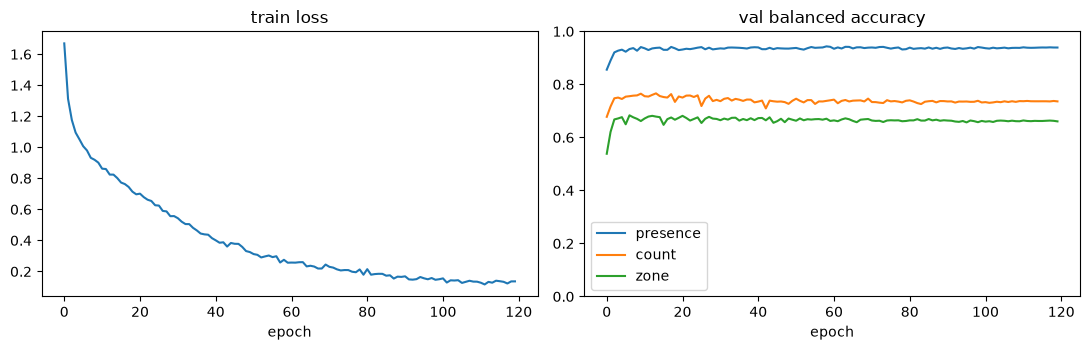

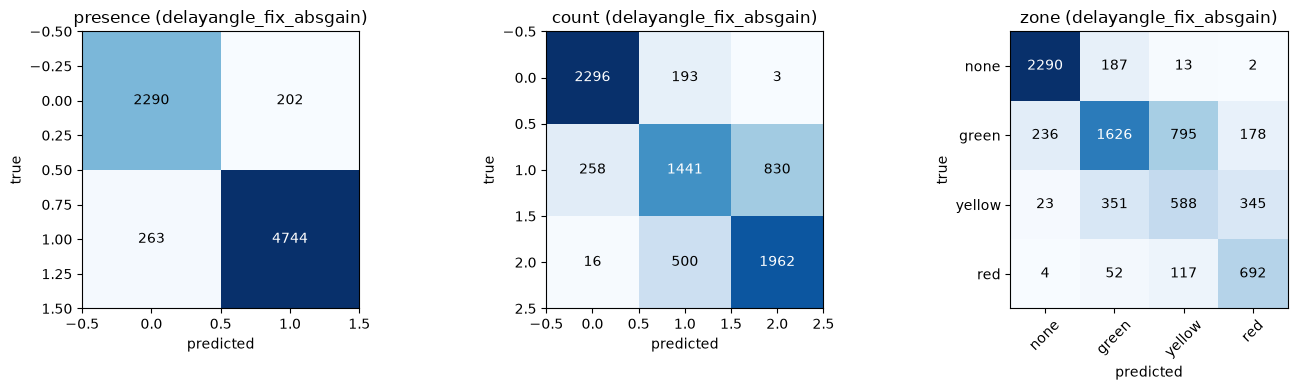

detection prob 0.947 | false-alarm (>=1 AGV) 0.108 | (0 AGV) 0.000
robustness vs #AGV:   #AGV     n   presAcc  countAcc  zoneBAcc  redRecall
          0   1839    0.972     0.812     0.733     0.806
          1   1845    0.951     0.776     0.708     0.828
          2   1988    0.932     0.748     0.664     0.792
          3   1827    0.897     0.704     0.637     0.774


In [10]:
# ================================================================
# DETAIL -- curves + confusion matrices + robustness for DETAIL_NAME
# ================================================================
d = DETAILS[DETAIL_NAME]; P, T, agv_te, hist = d['P'], d['T'], d['agv_te'], d['hist']
print('detailed view of run:', DETAIL_NAME)

# training curves
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(hist[:, 0]); ax[0].set_title('train loss'); ax[0].set_xlabel('epoch')
ax[1].plot(hist[:, 1], label='presence'); ax[1].plot(hist[:, 2], label='count'); ax[1].plot(hist[:, 3], label='zone')
ax[1].set_title('val balanced accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].set_ylim(0, 1)
fig.tight_layout(); plt.show()

# confusion matrices
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, (name, k) in zip(ax, [('presence', 'p'), ('count', 'c'), ('zone', 'z')]):
    cm = confusion_matrix(T[k], P[k]); a.imshow(cm, cmap='Blues'); a.set_title(f'{name} ({DETAIL_NAME})')
    a.set_xlabel('predicted'); a.set_ylabel('true')
    for (r, cc), v in np.ndenumerate(cm):
        a.text(cc, r, int(v), ha='center', va='center', color='white' if v > cm.max()/2 else 'black')
    if name == 'zone':
        a.set_xticks(range(4)); a.set_xticklabels(ZONE_NAMES, rotation=45)
        a.set_yticks(range(4)); a.set_yticklabels(ZONE_NAMES)
fig.tight_layout(); plt.show()

# detection vs false-alarm + robustness vs #AGV
noh = T['p'] == 0
print(f"detection prob {recall_score(T['p'], P['p'], pos_label=1):.3f} | "
      f"false-alarm (>=1 AGV) {float(P['p'][noh & (agv_te>=1)].mean()) if (noh&(agv_te>=1)).any() else float('nan'):.3f} | "
      f"(0 AGV) {float(P['p'][noh & (agv_te==0)].mean()) if (noh&(agv_te==0)).any() else float('nan'):.3f}")
if agv_te.max() > 0:
    print('robustness vs #AGV:   #AGV     n   presAcc  countAcc  zoneBAcc  redRecall')
    for ac in range(int(agv_te.max()) + 1):
        s = agv_te == ac
        if not s.any(): continue
        rr = recall_score(T['z'][s] == 3, P['z'][s] == 3) if (T['z'][s] == 3).any() else float('nan')
        print(f'   {ac:8d} {int(s.sum()):6d}    {(P["p"][s]==T["p"][s]).mean():.3f}     '
              f'{(P["c"][s]==T["c"][s]).mean():.3f}     {balanced_accuracy_score(T["z"][s], P["z"][s]):.3f}     {rr:.3f}')

In [11]:
# --- save the comparison table (per-run checkpoints already saved by run_experiment) ---
csv = os.path.join(BASE_DIR, 'results_experiments.csv')
results_df.to_csv(csv)
print('saved', csv)
print('per-run checkpoints: csi_multitask_<name>.pt in', BASE_DIR)
results_df.round(3)

saved c:\Users\u5737297\Documents\wifi sensing\stage2\results_experiments.csv
per-run checkpoints: csi_multitask_<name>.pt in c:\Users\u5737297\Documents\wifi sensing\stage2


,rep,zone,split,hybrid,addGain,seed,redMargin,distW,trainN,presAcc,countAcc,zoneAcc,zoneBAcc,redRecall,detProb,faClut,distMAE,bestVal,nTest
name,,,,,,,,,,,,,,,,,,,
delayangle_fix,delayangle,dist,stored,False,NaN,0,0.4,True,35002,0.946,0.764,0.685,0.681,0.797,0.954,0.095,0.749,0.802,7499
delayangle_fix_normmag,delayangle,dist,stored,False,norm,0,0.4,True,35002,0.940,0.768,0.718,0.682,0.731,0.936,0.070,0.725,0.800,7499
delayangle_fix_absgain,delayangle,dist,stored,False,abs,0,0.4,True,35002,0.938,0.760,0.693,0.686,0.800,0.947,0.108,0.746,0.794,7499


## Learning curve (of the current best model)

The learning curve trains the **current best model** — `delayangle_fix`
(delayangle representation + distance head + safety fix, **no** hybrid; the L3
physics hybrid washed out at 50k) — on growing slices of the training split
(**1k, 2k, 4k, 8k, 16k, 32k, and full ~35k**), with validation and test fixed.
It shows how the metrics scale with the amount of training **data**.

`RUN_LC = True` runs it in the SWEEP cell above; this cell plots `lc_df`.

**What it answers — and what it does not.** It answers the *data* question:
- if `zoneBAcc` is **still rising** at ~35k → more data is still paying off
  (worth generating a bigger set);
- if it has **flattened** → we are into **diminishing returns on data** — more
  samples won't move it much.

A flat curve means *more data* won't help. It does **not** prove an information
ceiling: the plateau could still be overfitting-limited (which the
regularisation / augmentation experiment tests) or movable by a different
representation / architecture. Do **not** read a flat curve as "this is the
maximum possible."

Watch `zoneBAcc` and `distMAE` (the continuous distance skill) alongside
`redRecall` (steadier now with ~6× more red samples).

In [12]:
# ================================================================
# LEARNING CURVE plot -- only if the LC was run (RUN_LC=True). For the
# v1.3 gain experiment RUN_LC=False, so this cell is a no-op.
# ================================================================
if not len(lc_df):
    print('learning-curve plot skipped (RUN_LC=False -> lc_df is empty).')
else:
    lc_df.to_csv(os.path.join(BASE_DIR, 'results_learning_curve.csv'), index=False)
    print('learning curve of', LC_NAME)
    print(lc_df.round(3).to_string(index=False))
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    for mtr in ['presAcc', 'countAcc', 'zoneBAcc']:
        ax[0].plot(lc_df['train_n'], lc_df[mtr], marker='o', label=mtr)
    ax[0].set_xlabel('training samples'); ax[0].set_ylabel('test metric')
    ax[0].set_title(f'learning curve ({LC_NAME})'); ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(lc_df['train_n'], lc_df['redRecall'], marker='o', color='red', label='red-recall')
    ax[1].plot(lc_df['train_n'], lc_df['faClut'], marker='o', color='gray', label='false-alarm (clutter)')
    ax[1].plot(lc_df['train_n'], lc_df['distMAE'], marker='o', color='green', label='distMAE (m)')
    ax[1].set_xlabel('training samples'); ax[1].set_title('safety / distance vs data')
    ax[1].legend(); ax[1].grid(alpha=0.3)
    fig.tight_layout(); plt.show()

learning-curve plot skipped (RUN_LC=False -> lc_df is empty).


## How to read the results

`results_df` (one row per run) is the comparison. Key columns: `presAcc`,
`countAcc`, `zoneAcc` / `zoneBAcc`, **`redRecall`** (the safety number),
`detProb`, `faClut`, `distMAE`, plus `hybrid`, `redMargin`, `distW`, `split`.

**The questions, and which rows answer them:**
1. **Safety fix (complex).** `dist_base` vs `dist_margin` / `dist_weighted` /
   `dist_both` vs `zone_clf`. Only `dist_both` recovers red-recall (both knobs).
2. **Representation.** `dist_base` vs `delay` vs `delayangle` — physics reps cut
   `distMAE` / false alarms and lift `zoneBAcc`.
3. **L3 physics hybrid — cleanly isolated (new in v1.1):**
   - *same-scene:* **`hybrid_best` vs `delayangle_fix`** (identical except the
     physics features) → does L3 help in-distribution?
   - *generalisation:* **`hybrid_best_gen` vs `delayangle_fix_gen`** (the same
     pair on the `clutter_holdout` split) → does L3 help TRANSFER to unseen
     clutter? Physics is expected to help mainly here.
   - *clutter penalty:* `hybrid_best` vs `hybrid_best_gen`, and `delayangle_fix`
     vs `delayangle_fix_gen`.
4. **Learning curve** (of `hybrid_best`, plotted below): is `zoneBAcc` still
   climbing with data, or flat (= a ceiling, not a data limit)?

Read `distMAE` as the continuous physical skill and `redRecall` / a binary-red
decision as the safety outcome; 4-class `zoneBAcc` is a harsh quantiser, and a
single-run `redRecall` is noisy (report 2–3 seeds for the write-up).

`hybrid_best` is trained once — the learning curve's full-size point — and reused
for the table and the `DETAIL` plots. Results → `results_df` +
`results_experiments.csv`; checkpoints `csi_multitask_<name>.pt`.